# Single Node debugging
In this notebook we test each function for its ability to handle an input network consisting of a single node, to (hopefully) figure out where our issues on the Cora network come from.

Only visible issue seems to be with the build_network_cache(), which yields a warning for the division and makes p nan but that doesn't affect the optimization outcome at all.

In [1]:
# library imports
import igraph as ig
import numpy as np
import infomap

import sys
sys.path.append("..") # go to parent folder
import src.map_equation as meq
import src.optimize as opt
from src.utils import visual_community_colors

Generating the test network:

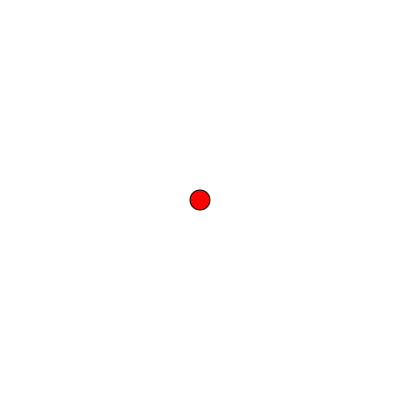

In [2]:
g = ig.Graph(n=1, directed=False)
#g = ig.Graph(n=1, directed=True)

ig.plot(g, **visual_community_colors(g))

In [3]:
g.summary()

'IGRAPH U--- 1 0 -- '

### Test Map equation computation

In [4]:
comms = g.community_infomap()
res_im = infomap.run(g, two_level=True, num_trials=1) 
print('custom: ', meq.compute_description_length(g, comms.membership))
print('igraph: ', comms.codelength)
print('infomap: ', res_im.codelength)

custom:  0.0
igraph:  0.0
infomap:  0.0


In [5]:
L, p, p_mod, exit_weights, scalars = meq.compute_description_length(g, comms.membership, returnTerms=True, verbose=True)
print("L: ", L)
print("p: ", p)
print("p_mod: ", p_mod)
print("exit_weights: ", exit_weights)
print("scalars: ", scalars)

L:  0.0
p:  [0.]
p_mod:  [0.]
exit_weights:  [0.]
scalars:  {'q_sum': 0.0, 'sum_xlogx_q': 0.0, 'sum_xlogx_ploop': 0.0, 'sum_xlogx_p': 0.0}


In [6]:
meq.update_node_move_description_length(g, comms.membership, p, p_mod, exit_weights, 0, 0, scalars_old=scalars, verbose=True) # update existing


d:\Studium\Information Theory\Project\ITI_project\notebooks\..\src\map_equation.py:822: UserWarning: Node already in target community 0! No change.
  warnings.warn(f"Node already in target community {comm_trg}! No change.")


In [7]:
try:
    meq.update_node_move_description_length(g, comms.membership, p, p_mod, exit_weights, 0, 1, scalars_old=scalars, verbose=True) # update existing
except:
    print("We aren't allowing new communities to be given to the update function.")

We aren't allowing new communities to be given to the update function.


### Testing full infomap + components

In [8]:
opt.build_graph_cache(g)

{'edges': array([], shape=(0, 2), dtype=int64),
 'weights': array([], dtype=float64),
 'total_weight_x2': 1.0,
 'out_strength': None,
 'adj': None,
 'p': array([0.]),
 'sum_xlogx_p': np.float64(0.0),
 'incidence': {'out_idxptr': array([0, 0]),
  'out_eids': array([], dtype=int64),
  'in_idxptr': array([0, 0]),
  'in_eids': array([], dtype=int64)},
 'neighborhood': [array([], dtype=int64)]}

Node movement optimization:

In [9]:
communities, L, p_mod, exit_data = opt.node_movement_optimization(g, returnTerms=True, verbose=True)
print(communities)
print(L)
print(p_mod)
print(exit_data)

Graph has only one node, returning it as the only community.
[0]
0.0
[0.]
[0.]


Network compression:

In [10]:
g_compressed, unique_communities = opt.compress_network(g, communities, verbose=True)
print(unique_communities)
g_compressed.summary()

Input graph has 1 unique communities, 1 nodes and 0 edges.
Creating compressed graph with 1 nodes, 0 aggregated edges.
[0]


'IGRAPH U--- 1 0 -- '

Core search algorithm:

In [11]:
comms = opt.core_search_algorithm(g, verbose=True)
print(comms)


--- Level 0 ------------------------------
    Current Graph: 1 nodes, 0 edges
Graph has only one node, returning it as the only community.
    Phase 1 found 1 communities
    Node movement did not improve codelength, stopping optimization.

Final: 1 communities, L = 0.000000 bits
[0]


Submodule refinement:

In [12]:
refined = opt.submodule_movement_optimization(g, verbose=True)

No initial partition provided, running core search algorithm first.

--- Level 0 ------------------------------
    Current Graph: 1 nodes, 0 edges
Graph has only one node, returning it as the only community.
    Phase 1 found 1 communities
    Node movement did not improve codelength, stopping optimization.

Final: 1 communities, L = 0.000000 bits
Submodule refinement: Starting with 1 modules, 1 nodes and 0 edges total.
Initial description length: 0.00 bits.

--- Parent module 0 ---
Nodes: 1
Subgraph: 1 nodes, 0 edges
Base case reached with singleton node (N=1). Stopping recursion.
n_submodules: 1
offset: 0
Created 1 submodules across 1 modules.
Input graph has 1 unique communities, 1 nodes and 0 edges.
Creating compressed graph with 1 nodes, 0 aggregated edges.
  Compressed nodes: 1, unique initial communities: 1
Graph has only one node, returning it as the only community.
Submodule refinement complete: 1 -> 1 communities.
Description length: 0.0 -> 0.0


Search community partition (full Infomap search):

In [13]:
comms = opt.search_community_partition(g, num_restarts=1, verbose=True)

--- Running community search ---------------------------------------
Input Graph: 1 nodes, 0 edges

--- Run 1/1:  Starting community partition search... -------
Starting from description length L = 0.0 bits (with trivial parititon)

--- Level 0 ------------------------------
    Current Graph: 1 nodes, 0 edges
Graph has only one node, returning it as the only community.
    Phase 1 found 1 communities
    Node movement did not improve codelength, stopping optimization.

Final: 1 communities, L = 0.000000 bits
Initial partition found by core search algorithm has description length L = 0.000000 bits
--- Starting refinement process...


--- Refinement: Starting Iteration 1
Submodule refinement: Starting with 1 modules, 1 nodes and 0 edges total.
Initial description length: 0.00 bits.

--- Parent module 0 ---
Nodes: 1
Subgraph: 1 nodes, 0 edges
Base case reached with singleton node (N=1). Stopping recursion.
n_submodules: 1
offset: 0
Created 1 submodules across 1 modules.
Input graph has 1